In [1]:
import requests
import pandas as pd
from bs4 import BeautifulSoup

In [ ]:
url="https://www.boxofficemojo.com/year/"

In [3]:
content = requests.get(url)

In [4]:
content.text[:300]

'<!doctype html><html class="a-no-js" data-19ax5a9jf="dingo"><head><script>var aPageStart = (new Date()).getTime();</script><meta charset="utf-8"/>\n<script type=\'text/javascript\'>var ue_t0=ue_t0||+new Date();</script>\n<script type=\'text/javascript\'>\nwindow.ue_ihb = (window.ue_ihb || window.ueinit || '

In [5]:
soup = BeautifulSoup(content.text,'html.parser')

In [6]:
len(soup)

2

In [7]:
year = []
gross = []
ly = []
theater = []
average = []
top = []
link = []

In [11]:
for row in soup.find('table').find_all('tr')[1:]:
    year.append(row.find_all('td')[0].text.strip())
    gross.append(row.find_all('td')[1].text.strip())
    ly.append(row.find_all('td')[2].text.strip())
    theater.append(row.find_all('td')[3].text.strip())
    average.append(row.find_all('td')[4].text.strip())
    top.append(row.find_all('td')[5].text.strip())
    link.append('https://www.boxofficemojo.com/year/'+row.find_all('td')[0].text.strip())


In [15]:
print(year)

['2026', '2025', '2024', '2023', '2022', '2021', '2020', '2019', '2018', '2017', '2016', '2015', '2014', '2013', '2012', '2011', '2010', '2009', '2008', '2007', '2006', '2005', '2004', '2003', '2002', '2001', '2000', '1999', '1998', '1997', '1996', '1995', '1994', '1993', '1992', '1991', '1990', '1989', '1988', '1987', '1986', '1985', '1984', '1983', '1982', '1981', '1980', '1979', '1978', '1977']


In [9]:
df1=pd.DataFrame({
    'Year':year,
    'GrossAmt':gross,
    'Ly+-':ly,
    'Theater':theater,
    'AverageAmt':average,
    'Top_Movie':top,
    'Link':link
    })

In [24]:
df1.count()

Year          0
GrossAmt      0
Ly+-          0
Theater       0
AverageAmt    0
Top_Movie     0
Link          0
dtype: int64

In [17]:
len(ly)

50

In [16]:
display(df1)

,Year,GrossAmt,Ly+-,Theater,AverageAmt,Top_Movie,Link


In [13]:
df1.shape

(0, 7)

In [25]:
df1.Link[ :4]

Series([], Name: Link, dtype: float64)

In [26]:
rank = []
movie = []
gross = []
theater = []
release_date = []
distributor = []

In [27]:
for url in df1['Link']:
    content = requests.get(url)
    soup = BeautifulSoup(content.text,'html.parser')
    for row in soup.find('table').find_all('tr')[1:]:
        rank.append(row.find_all('td')[0].text.strip())
        movie.append(row.find_all('td')[1].text.strip())
        gross.append(row.find_all('td')[5].text.strip())
        theater.append(row.find_all('td')[6].text.strip().replace(',',''))
        release_date.append(row.find_all('td')[8].text.strip()+" "+url[-4::])
        distributor.append(row.find_all('td')[9].text.strip())

In [28]:
df2 = pd.DataFrame({
    'Rank':rank,
    'Movie':movie,
    'GrossAmt':gross,
    'Theater':theater,
    'Release Date':release_date,
    'Distributor':distributor
})

In [29]:
df2.shape


(0, 6)

In [30]:
df2.head()


,Rank,Movie,GrossAmt,Theater,Release Date,Distributor


In [31]:
df2.to_csv("All_Movies_Data.csv")


In [32]:
import matplotlib.pyplot as plt


In [33]:
mbd = df2.groupby('Distributor').agg({'Movie':'count'}).reset_index()

In [34]:
mbd

,Distributor,Movie


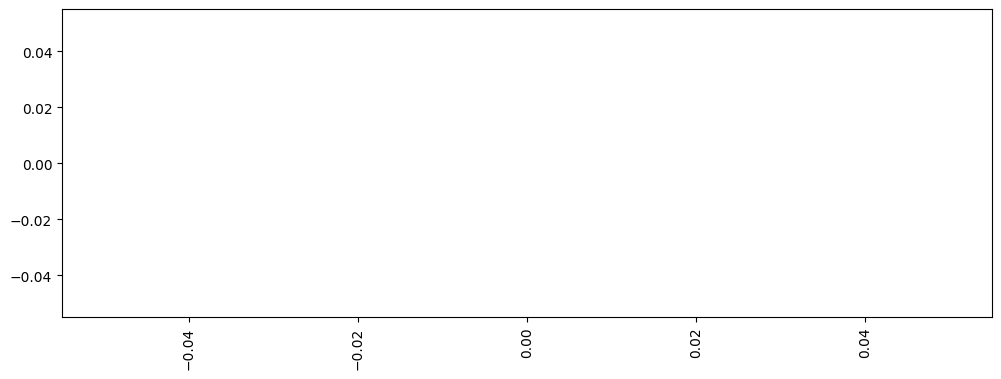

In [35]:
plt.figure(figsize=(12,4))
plt.bar(mbd['Distributor'],mbd['Movie'])
plt.xticks(rotation=90)
plt.show()